# World Population Analysis 2022-2025

**Tools:** Python, Pandas, Matplotlib

## Project Overview
This project analyzes world population data from 2022 and 2025, 
combining two datasets to calculate real growth metrics and uncover 
global population trends.

## Key Questions Answered
1. Which are the top 10 most populated countries in 2025?
2. Which countries grew fastest between 2022 and 2025?
3. Which continents are growing vs shrinking?
4. Which countries added the most people in absolute numbers?
5. Where does Sri Lanka stand in the world? 

## Data Loading

In [2]:
import pandas as pd

df_2022 = pd.read_csv("./world_population.csv")
df_2025 = pd.read_csv("./world_population_2025.csv")

print("2022 dataset", df_2022.shape)
print("2025 dataset", df_2025.shape)

2022 dataset (234, 17)
2025 dataset (233, 12)


In [3]:
df_2022.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [4]:
df_2025.head()

,id,Country (or dependency),Population 2025,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,India,1463865525,0.89%,12929734,492,2973190,"−495,753",1.94,28.8,37.1%,17.78%
1,2,China,1416096094,−0.23%,"−3,225,184",151,9388211,"−268,126",1.02,40.1,67.5%,17.20%
2,3,United States,347275807,0.54%,1849236,38,9147420,1230663,1.62,38.5,82.8%,4.22%
3,4,Indonesia,285721236,0.79%,2233305,158,1811570,"−39,509",2.10,30.4,59.6%,3.47%
4,5,Pakistan,255219554,1.57%,3950390,331,770880,"−1,235,336",3.50,20.6,34.4%,3.10%


## Data Cleaning & Preparation

In [4]:
df_merged = pd.merge(df_2022[['Country/Territory','Continent','2022 Population']],
                    df_2025[['Country (or dependency)','Population 2025']],
                    left_on ='Country/Territory',
                    right_on = 'Country (or dependency)',
                    how = 'inner' 
                    )

print("Merged dataset shape: ",df_merged.shape)
print(df_merged.head())

Merged dataset shape:  (214, 5)
  Country/Territory Continent  2022 Population Country (or dependency)  \
0       Afghanistan      Asia         41128771             Afghanistan   
1           Albania    Europe          2842321                 Albania   
2           Algeria    Africa         44903225                 Algeria   
3    American Samoa   Oceania            44273          American Samoa   
4           Andorra    Europe            79824                 Andorra   

   Population 2025  
0         43844111  
1          2771508  
2         47435312  
3            46029  
4            82904  


In [20]:
print(df_merged.isnull().sum())

Country/Territory          0
Continent                  0
2022 Population            0
Country (or dependency)    0
Population 2025            0
dtype: int64


## Feature Engineering

In [22]:
df_merged['Population Growth'] = df_merged['Population 2025']- df_merged['2022 Population']

In [26]:
df_merged['Growth %'] = (df_merged['Population Growth']/df_merged['2022 Population'])*100

In [28]:
df_merged['Growth %']= df_merged['Growth %'].round(2)

In [30]:
df_merged.head()

,Country/Territory,Continent,2022 Population,Country (or dependency),Population 2025,Population Growth,Growth %
0,Afghanistan,Asia,41128771,Afghanistan,43844111,2715340,6.60
1,Albania,Europe,2842321,Albania,2771508,-70813,-2.49
2,Algeria,Africa,44903225,Algeria,47435312,2532087,5.64
3,American Samoa,Oceania,44273,American Samoa,46029,1756,3.97
4,Andorra,Europe,79824,Andorra,82904,3080,3.86


## Q1 — Top 10 Most Populated Countries 2025
India is the world's most populated country, with 1.46 billion people.
Long time dominator China recieved the second place. 
The USA sits a distant third with 347 million.

In [34]:
top10_2025 = df_merged[['Country/Territory','Population 2025']].sort_values(by = 'Population 2025', ascending = False).head(10)

In [1]:
import matplotlib.pyplot as plt

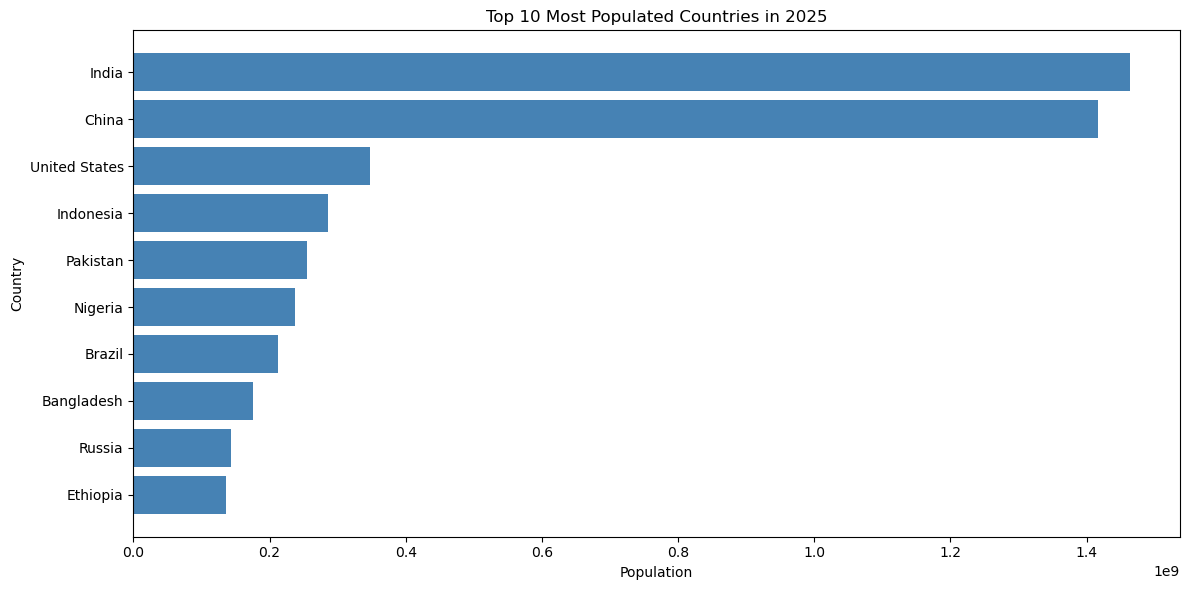

In [48]:
plt.figure(figsize = (12,6))
plt.barh(top10_2025['Country/Territory'],top10_2025['Population 2025'], color = 'steelblue')
plt.xlabel('Population')
plt.ylabel('Country')
plt.title('Top 10 Most Populated Countries in 2025')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Q2 — Fastest Growing Countries 2022-2025
Small territories like Tokelau and British Virgin Islands dominate percentage 
growth — highlighting how percentage can be misleading for tiny populations.

In [54]:
fastest_growing = df_merged[['Country/Territory','Growth %']].sort_values(by = 'Growth %',ascending = False).head(10)

In [55]:
print(fastest_growing)

          Country/Territory  Growth %
193                 Tokelau     39.39
28   British Virgin Islands     26.92
211                   Yemen     23.97
169              Seychelles     23.96
72                Gibraltar     22.90
133                 Namibia     20.48
202    United Arab Emirates     20.18
147                    Oman     20.07
38                     Chad     18.51
198            Turkmenistan     18.47


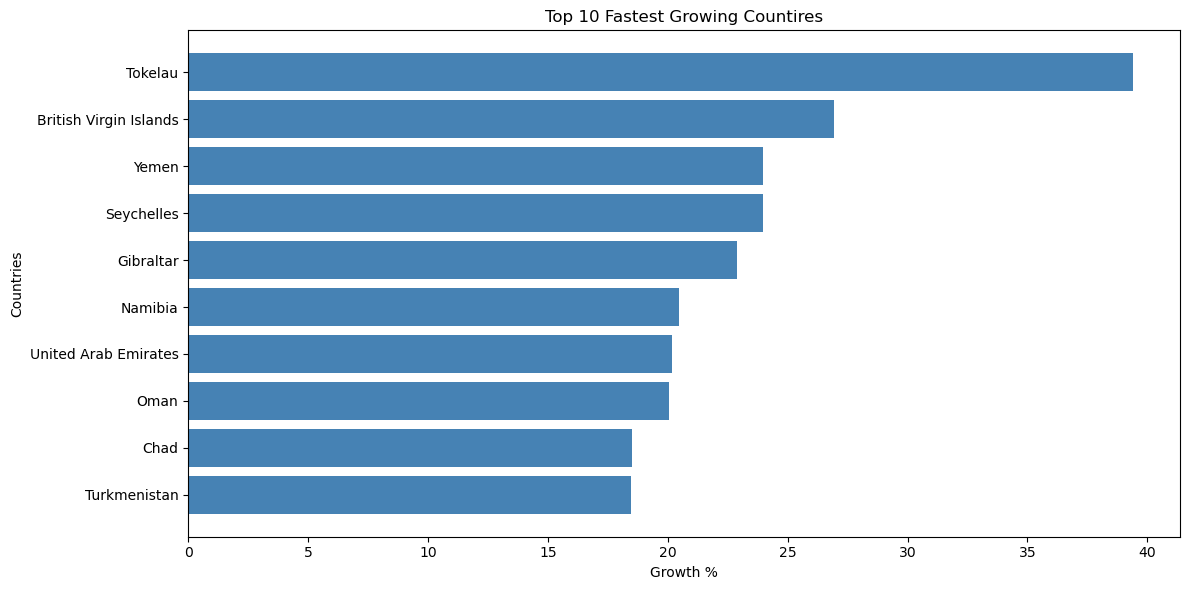

In [116]:
plt.figure(figsize = (12,6))
plt.barh(fastest_growing['Country/Territory'],fastest_growing['Growth %'], color ='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Growth %')
plt.ylabel('Countries')
plt.title('Top 10 Fastest Growing Countires')
plt.tight_layout()
plt.show()

## Q3 — Continent Growth Comparison
Africa is the fastest growing continent at 7.75% average growth. 
Oceania is the only continent with negative growth at -0.54%.

In [78]:
continent_growth = df_merged.groupby('Continent')['Growth %'].mean().round(2).reset_index()
continent_growth.columns = ['Continent','Average Growth %']
continent_growth = continent_growth.sort_values(by='Average Growth %', ascending = False)

In [79]:
print(continent_growth)

       Continent  Average Growth %
0         Africa              7.75
1           Asia              5.56
3  North America              1.07
5  South America              1.05
2         Europe              0.62
4        Oceania             -0.54


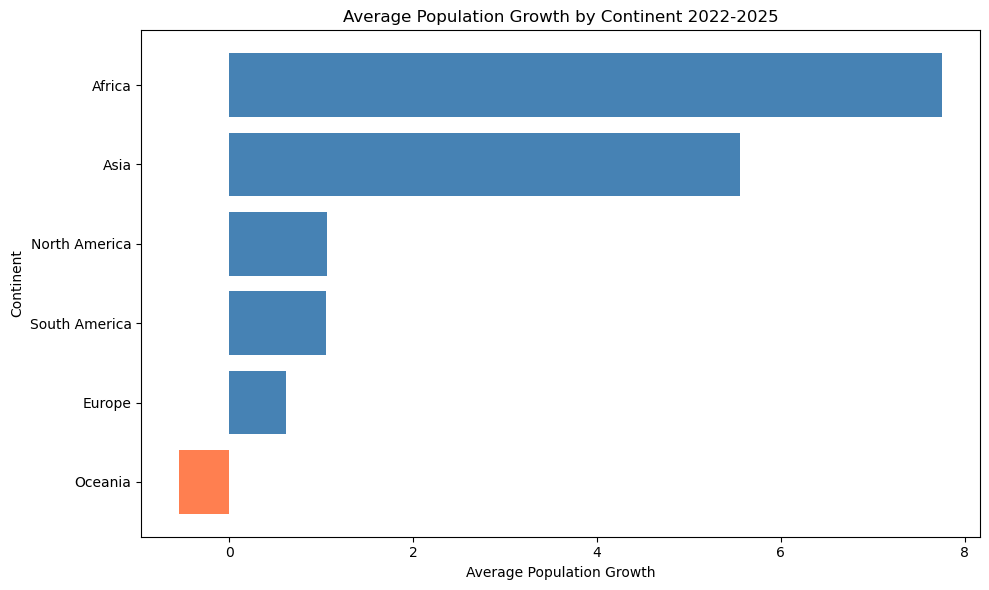

In [87]:
color = ['coral' if x < 0 else 'steelblue' for x in continent_growth['Average Growth %']]

plt.figure(figsize = (10,6))
plt.barh(continent_growth['Continent'],continent_growth['Average Growth %'],color = color )
plt.gca().invert_yaxis()
plt.title('Average Population Growth by Continent 2022-2025')
plt.xlabel('Average Population Growth')
plt.ylabel('Continent')
plt.tight_layout()
plt.show()

## Q4 — Biggest Absolute Population Growth
India added 46 million people in just 3 years — more than the entire 
population of Sri Lanka multiplied four times over.

In [90]:
biggest_growth = df_merged[['Country/Territory','Population Growth']].sort_values(by ='Population Growth', ascending = False ).head(10)

In [91]:
biggest_growth.head(10)

,Country/Territory,Population Growth
87,India,46692352
148,Pakistan,19394692
141,Nigeria,18986570
52,DR Congo,13822261
60,Ethiopia,12092127
88,Indonesia,10219897
204,United States,8985950
211,Yemen,8077264
54,Egypt,7375892
189,Tanzania,5048117


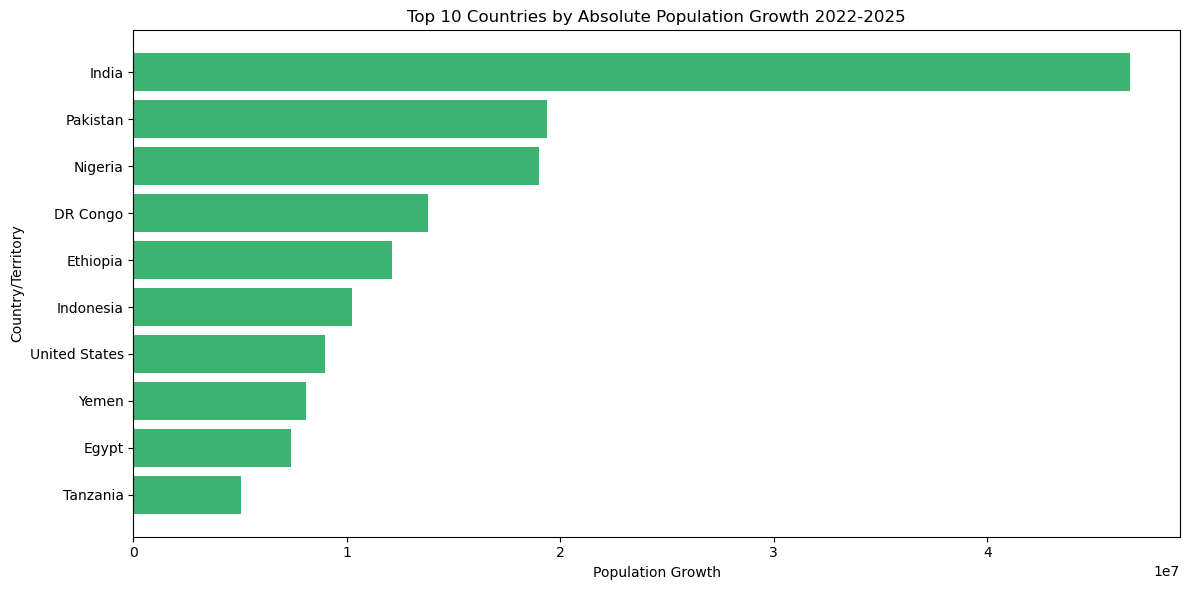

In [99]:
plt.figure(figsize = (12,6))
plt.barh(biggest_growth['Country/Territory'],biggest_growth['Population Growth'], color = 'mediumseagreen')
plt.gca().invert_yaxis()
plt.title('Top 10 Countries by Absolute Population Growth 2022-2025')
plt.xlabel('Population Growth')
plt.ylabel('Country/Territory')
plt.tight_layout()
plt.show()

## Q5 — Sri Lanka's Global Position
Sri Lanka ranks #55 globally with a population of 23.2 million in 2025, 
growing 6.4% since 2022.

In [100]:
sri_lanka = df_merged[df_merged['Country/Territory'] == 'Sri Lanka']

In [101]:
print(sri_lanka[['Country/Territory','Continent','2022 Population', 'Population 2025', 'Population Growth', 'Growth %']])

    Country/Territory Continent  2022 Population  Population 2025  \
181         Sri Lanka      Asia         21832143         23229470   

     Population Growth  Growth %  
181            1397327       6.4  


In [106]:
df_merged_ranked = df_merged.sort_values(by = 'Population 2025', ascending = True).reset_index(drop=True)
df_merged_ranked['Rank'] = df_merged_ranked.index +1
sl_rank = df_merged_ranked[df_merged_ranked['Country/Territory']=='Sri Lanka']['Rank']

print(f"Sri Lanka's Rank: #{sl_rank}")

Sri Lanka's Rank: #155    156
Name: Rank, dtype: int64


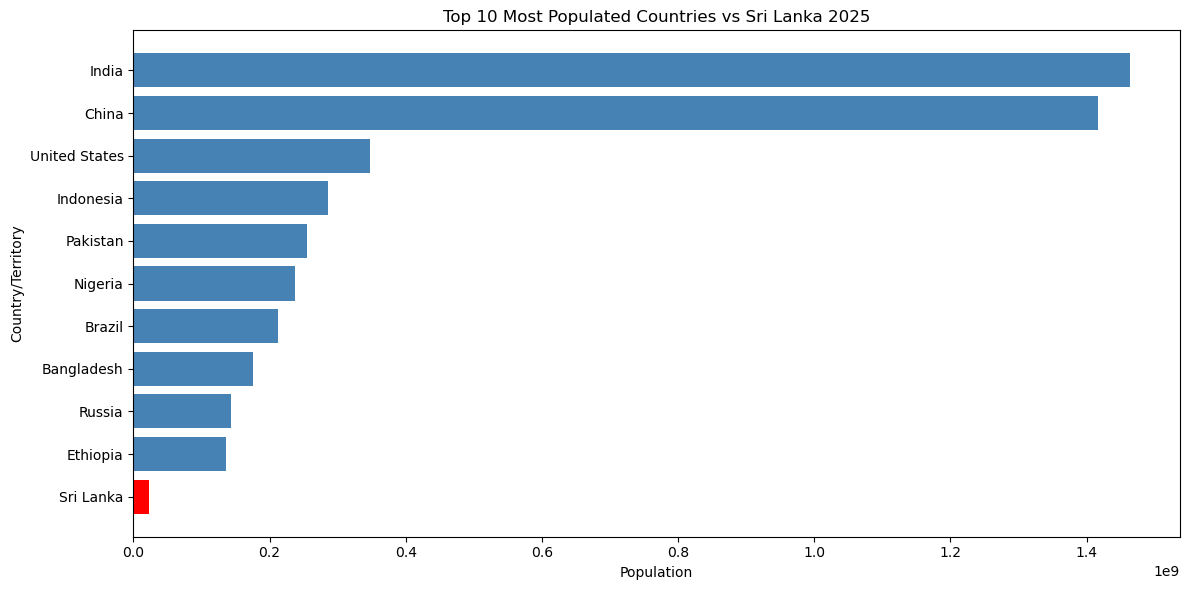

In [115]:
top10_2025_with_sl = pd.concat([top10_2025, sri_lanka[['Country/Territory','Population 2025']]]).drop_duplicates()

color = ['red' if x == 'Sri Lanka' else 'steelblue' for x in top10_2025_with_sl['Country/Territory']]

plt.figure(figsize = (12,6))
plt.barh(top10_2025_with_sl['Country/Territory'], top10_2025_with_sl['Population 2025'] ,color = color)
plt.gca().invert_yaxis()
plt.title('Top 10 Most Populated Countries vs Sri Lanka 2025')
plt.xlabel('Population')
plt.ylabel('Country/Territory')
plt.tight_layout()
plt.show()

# Key Findings

- India remained the world's most populous country.
- Small territories showed the highest percentage growth.
- Africa recorded the strongest average continental growth.
- India added roughly 46 million people between 2022 and 2025.
- Sri Lanka ranked 55th globally by population.

# Conclusion

This analysis compared global population data between 2022 and 2025 to identify trends in population size and growth. The results showed that India remained the world's most populous country and experienced substantial population growth during the period. While the largest countries continued to dominate global population rankings, several smaller countries recorded the highest percentage growth rates.

The analysis also highlighted differences in growth patterns across continents, demonstrating that population change is not evenly distributed around the world. Additionally, Sri Lanka's global population ranking provided useful context for understanding its position relative to other nations.

Overall, the project demonstrates how data analysis can be used to transform raw population data into meaningful insights.